In [1]:
%matplotlib inline
import sys

sys.path.append('../../../')


import matplotlib.pyplot as plt

In [2]:
from __future__ import annotations

import gc
import math
import time
import os
import warnings
from copy import copy, deepcopy
from pathlib import Path

import numpy as np
import torch
from torch import nn, optim

%load_ext autoreload
%autoreload 2

from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.yolov11_pose.utils import DEFAULT_CFG_DICT
from computer_vision.yolov11_pose.cfg import get_cfg
from computer_vision.yolov11_pose.model.trainer import PoseTrainer
from computer_vision.yolov11_pose.utils.files import get_latest_run
from computer_vision.yolov11_pose.data.utils import check_det_dataset
from computer_vision.yolov11_pose.utils.checks import check_imgsz
from computer_vision.yolov11_pose.data.build import build_yolo_dataset, build_dataloader
from computer_vision.yolov11_pose.utils.torch_utils import unwrap_model, one_cycle, EarlyStopping

In [4]:
small=True

if small:
    input_dirpath='D:/data/ultralytics/coco8-pose/images'
    data_config='../coco8-pose.yaml'
    arguments=f'''
    --model-cfg ../yolo11-pose.yaml
    --train_image-dir {input_dirpath}/train
    --val_image-dir {input_dirpath}/val
    --save-dir {output_dirpath} 
    --checkpoint-dir {output_dirpath}/checkpoints
    --data {data_config} --resume --visualize
    --device cpu 
    '''
else:
    input_dirpath='D:/data/ultralytics/coco-pose/images'
    data_config='../coco-pose.yaml'
    arguments=f'''
    --model-cfg ../yolo11-pose.yaml
    --train_image-dir {input_dirpath}/train2017
    --val_image-dir {input_dirpath}/val2017
    --save-dir {output_dirpath} 
    --checkpoint-dir {output_dirpath}/checkpoints
    --data {data_config} --resume --visualize
    --device cpu 
    '''
output_dirpath='D:/results/yolov11_pose/training'

args=parser.parse_args(arguments.split())
trainer=PoseTrainer(cfg=args.model_cfg, overrides=args)


In engine.trainer.DetectionTrainer.__init__ self.args.data ../coco8-pose.yaml
In data.utils.check_det_dataset type(dataset) <class 'str'> 


In [6]:
# def _do_train(self):
"""Train the model with the specified world size"""
trainer._setup_train()

nb=len(trainer.train_loader) # number of batches
## self.args.warmup_epochs is the number of epochs spent warming up the optimizer
## we multiply self.args.warmup_epochs by nb since training updates happen per batch (iteration)
## warm up over nw optimization steps/iterations, i.e., nw is the number of time we will perform learning-rate adjustment for warmup
# nw=max(round(trainer.args.warmup_epochs*nb), 100) if trainer.args.warmup_epochs>0 else -1 
last_opt_step=-1
trainer.epoch_time=None
trainer.epoch_time_start=time.time()
trainer.train_time_start=time.time()
print(f"Image sizes {trainer.args.imgsz} train, {trainer.args.imgsz} val\n"
      f"Using {trainer.train_loader.num_workers *(trainer.world_size or 1)} dataloader workers\n"
      f"Logging results to {trainer.save_dir}\n"
      f"Starting training for "+(f"{trainer.args.time} hours..." if trainer.args.time else f"{trainer.epochs} epochs...")
)
if trainer.args.close_mosaic:
    base_idx=(trainer.epochs-trainer.args.close_mosaic)*nb # batch iterations in which close_mosaic start
    trainer.plot_idx.extend([base_idx, base_idx+1, base_idx+2])
epoch=trainer.start_epoch
trainer.optimizer.zero_grad() # zero any resumed gradients to ensure stability on training start
while True:
    trainer.epoch=epoch
    with warnings.catch_warnings():
        warnings.simplefilter('ignore') # suppress 'Detected lr_scheduler.step() before optimizer.step()'
        trainer.scheduler.step()
    trainer._model_train()
    # Update dataloader attributes 
    if epoch==(trainer.epochs - trainer.args.close_mosaic): 
        # TODO: test to see whether we get non-mosaic images after we close the mosaic
        # set args.plot to true to save a few training images
        trainer._close_dataloader_mosaic()
        #trainer.train_loader.reset()
    last_opt_step=trainer.train_each_epoch(epoch, last_opt_step)
    trainer.lr={f'lr/pg{ir}':x['lr'] for ir, x in enumerate(trainer.optimizer.param_groups)}
    # self.ema.update_attr(self.model, include=["yaml", "nc", "args", "names", "stride", "class_weights"])

    # Validation
    final_epoch=epoch+1>=trainer.epochs
    if trainer.args.val or final_epoch or trainer.stopper.possible_stop or trainer.stop:
        trainer._clear_memory(threshold=0.5) # prevent VRAM spike
        #trainer.metric, trainer.fitness=trainer.validate()
    break
print('nb ', nb, ' nw ', nw, ' trainer.args.warmup_epochs ', trainer.args.warmup_epochs, ' base_idx ', base_idx)

D:\dev\computer_vision\yolov11_pose\notebook\../../..\computer_vision\yolov11_pose\engine\trainer.py:316: UserWarning: Freezing layer 'model.23.dfl.conv.weight'
  warnings.warn(f"Freezing layer '{k}'")


In data.build.build_yolo_dataset batch 16
In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco8-pose\labels\train.cache
Scanning D:\data\ultralytics\coco8-pose\labels\train.cache... 8 images, 0 backgrounds, 0 corrupts
In data.dataset.YOLODataset.__init__ augment True rect False
In data.build.build_dataloader batch 16
In data.build.build_yolo_dataset batch 32
In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco8-pose\labels\val.cache
Scanning D:\data\ultralytics\coco8-pose\labels\val.cache... 4 images, 0 backgrounds, 0 corrupts
In data.dataset.YOLODataset.set_rectangle bi [0 0 0 0] nb 1
In data.dataset.YOLODataset.__init__ augment False rect True
In data.build.build_dataloader batch 32
Plotting labels to D:\results\yolov11_pose\training\labels.jpg... 
'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0', and 'momentum' automatically....
'optimizer:' AdamW(lr=0.002, momentum=0.9) with paramete

NotImplementedError: Please implement me, see https://github.com/ultralytics/ultralytics/blob/main/ultralytics/nn/tasks.py#L551

In [27]:
trainer.tloss

In [24]:
max(1, int(np.interp(ni, xi, [1, trainer.args.nbs/trainer.batch_size]).round()))

1

In [6]:
from computer_vision.misc import alpha_bending, instance2mask

from matplotlib import patches
import matplotlib.pyplot as plt
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy
from computer_vision.yolov11_pose.utils.viz import general_skeleton_overlay

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

0,1,

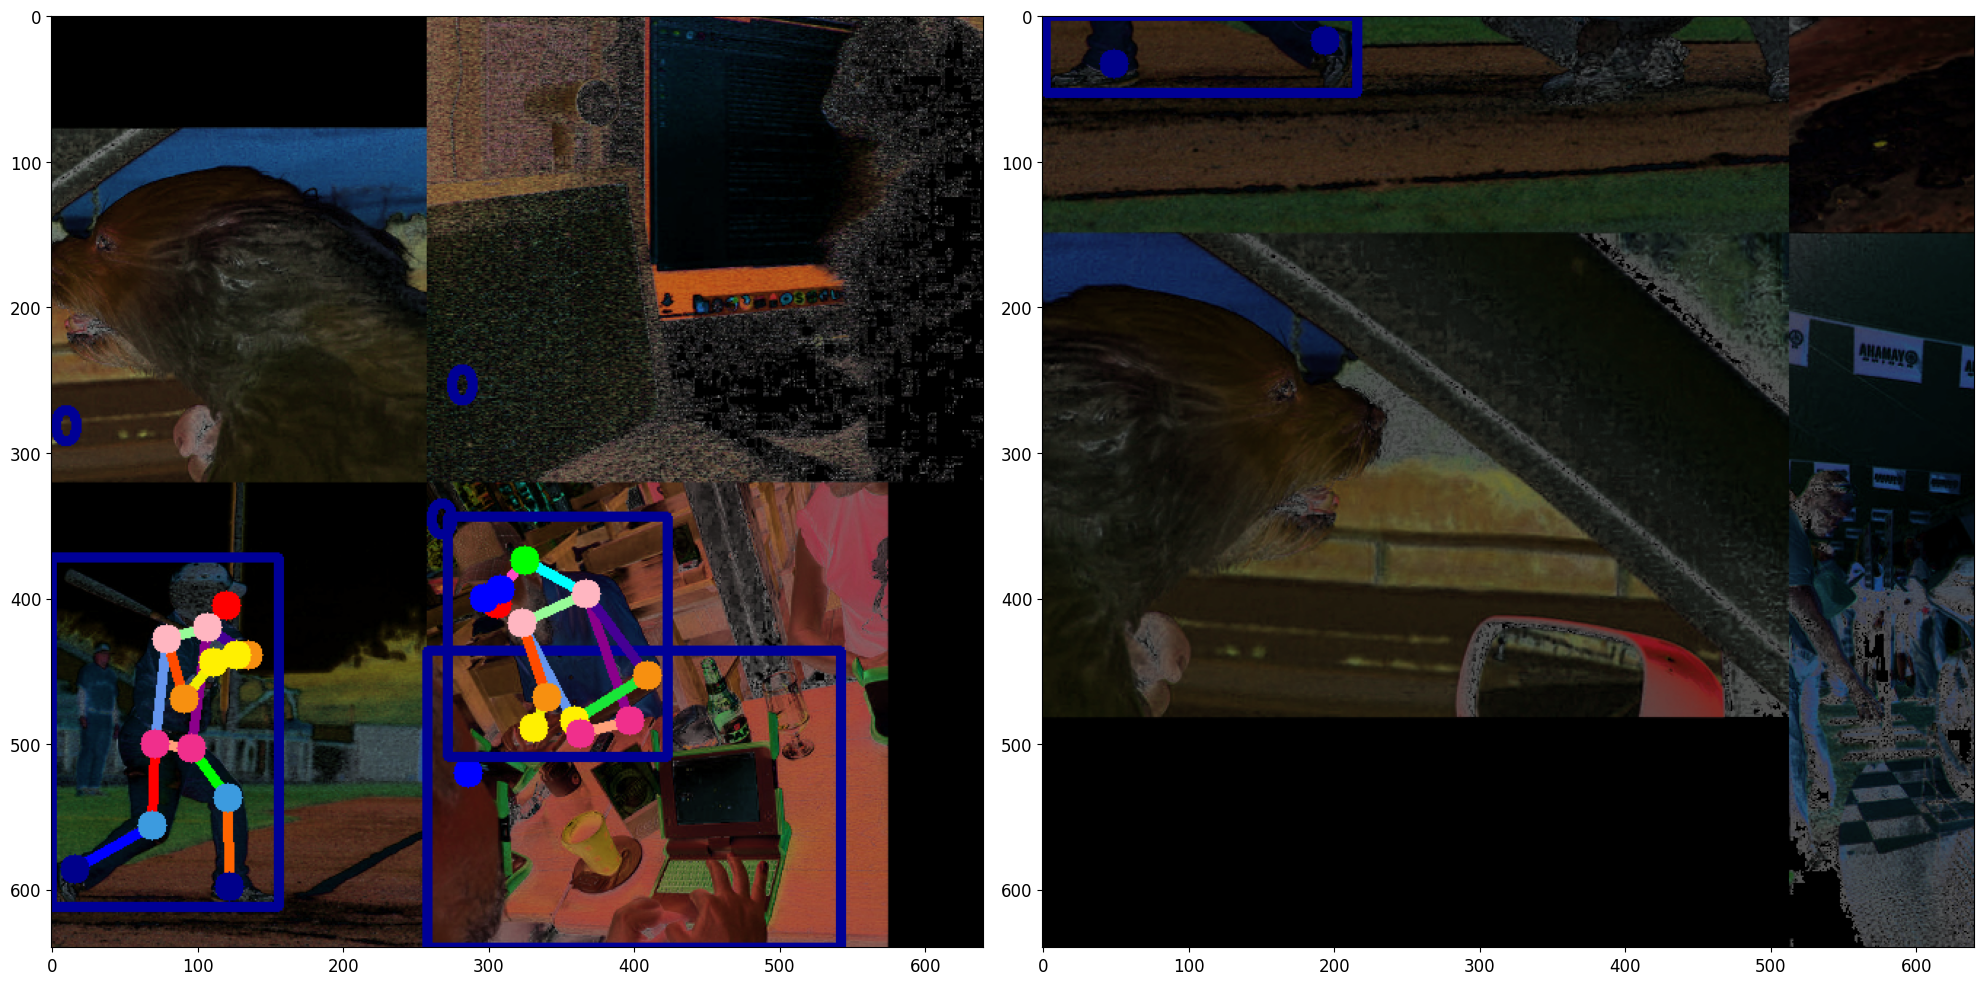

In [14]:
n_data=2
ncols=2
nrows=int(np.ceil(n_data/ncols))

_, ax=plt.subplots(nrows,ncols,figsize=(20,20))
for idx, item in enumerate(trainer.train_loader):
    if idx==n_data: break
    print(idx, end=',')
    batch_idx=item['batch_idx']
    flag=batch_idx==idx

    classes=item['cls'][flag].flatten() # (N,1) to (N,)
    classes=[f'{int(c)}' for c in classes]
    img=item['img'][idx] # (C,H,W)
    height, width=img.shape[-2:]
    if isinstance(img, torch.Tensor):
        img=img.permute(1,2,0).contiguous().numpy() # HxWxC
        img=img[...,::-1] # RGB to BGR

    bboxes=item['bboxes'][flag].clone()
    bboxes=xywh2xyxy(bboxes)
    # denormalize bboxes
    bboxes[...,[0,2]]*=width
    bboxes[...,[1,3]]*=height
    bboxes=bboxes.numpy()
    
    keypoints=item['keypoints'][flag].clone() if 'keypoints' in item else None # NxMx3
    if keypoints is not None: # denormalized
        keypoints[...,0]*=width
        keypoints[...,1]*=height
        keypoints=keypoints.numpy()
    if keypoints is not None:
        img=general_skeleton_overlay(img_bgr=img, class_names=classes, bboxes=bboxes, keypoints=keypoints)
        ax[idx].imshow(img[...,::-1])
    else: ax[idx].imshow(img[...,::-1])
    if keypoints is None:
        for j, (box,cls) in enumerate(zip(bboxes, classes)):
            # Create a Rectangle patch
            rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
            # Add the patch to the Axes
            ax[idx].add_patch(rect)
            ax[idx].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)

plt.tight_layout()


In data.dataset.YOLODataset.__getitem__ index 0
In data.dataset.YOLODataset.get_image_and_label index 0 self.batch[index] 0 [320 672]
data.augment.LetterBox.__call__ new_shape [320 672]
data.augment.LetterBox.__call__ img (320, 672, 3)
In data.dataset.YOLODataset.__getitem__ index 1
In data.dataset.YOLODataset.get_image_and_label index 1 self.batch[index] 0 [320 672]
data.augment.LetterBox.__call__ new_shape [320 672]
data.augment.LetterBox.__call__ img (320, 672, 3)
In data.dataset.YOLODataset.__getitem__ index 2
In data.dataset.YOLODataset.get_image_and_label index 2 self.batch[index] 0 [320 672]
data.augment.LetterBox.__call__ new_shape [320 672]
data.augment.LetterBox.__call__ img (320, 672, 3)
In data.dataset.YOLODataset.__getitem__ index 3
In data.dataset.YOLODataset.get_image_and_label index 3 self.batch[index] 0 [320 672]
data.augment.LetterBox.__call__ new_shape [320 672]
data.augment.LetterBox.__call__ img (320, 672, 3)
In data.dataset.YOLODataset.__getitem__ index 4
In data.

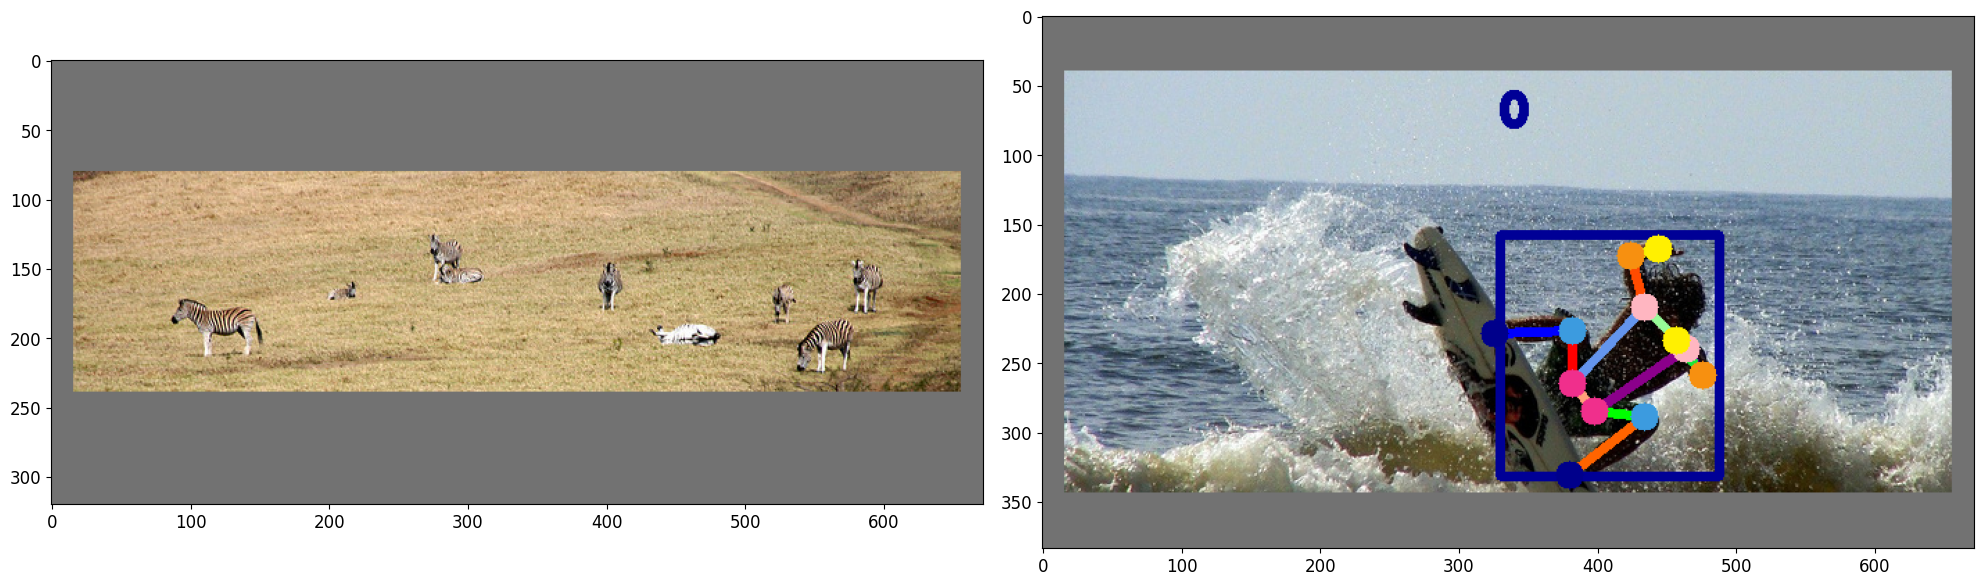

In [11]:
n_data=2
ncols=2
nrows=int(np.ceil(n_data/ncols))

_, ax=plt.subplots(nrows,ncols,figsize=(20,20))
for idx, item in enumerate(trainer.test_loader):
    if idx==n_data: break
    print(idx, end=',')
    batch_idx=item['batch_idx']
    flag=batch_idx==idx

    classes=item['cls'][flag].flatten() # (N,1) to (N,)
    classes=[f'{int(c)}' for c in classes]
    img=item['img'][idx] # (C,H,W)
    height, width=img.shape[-2:]
    if isinstance(img, torch.Tensor):
        img=img.permute(1,2,0).contiguous().numpy() # HxWxC
        img=img[...,::-1] # RGB to BGR

    bboxes=item['bboxes'][flag].clone()
    bboxes=xywh2xyxy(bboxes)
    # denormalize bboxes
    bboxes[...,[0,2]]*=width
    bboxes[...,[1,3]]*=height
    bboxes=bboxes.numpy()
    
    keypoints=item['keypoints'][flag].clone() if 'keypoints' in item else None # NxMx3
    if keypoints is not None: # denormalized
        keypoints[...,0]*=width
        keypoints[...,1]*=height
        keypoints=keypoints.numpy()
    if keypoints is not None:
        img=general_skeleton_overlay(img_bgr=img, class_names=classes, bboxes=bboxes, keypoints=keypoints)
        ax[idx].imshow(img[...,::-1])
    else: ax[idx].imshow(img[...,::-1])
    if keypoints is None:
        for j, (box,cls) in enumerate(zip(bboxes, classes)):
            # Create a Rectangle patch
            rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
            # Add the patch to the Axes
            ax[idx].add_patch(rect)
            ax[idx].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)

plt.tight_layout()
